# The Mandelbrot Set

## Mini-project step 1: Naive, NumPy, Numba

This project focuses on computing and visualizing the Mandelbrot set, which is a fractal defined over the complex plane. The set is defined by the quadratic complex mapping $z_{i+1} = z_i^2 + c$ starting from $z_0 = 0$. A complex point $c$ belongs to the Mandelbrot set if the sequence remains bounded. In practice, we use the threshold $|z| > 2$ because it is sufficient to guarantee divergence.

The computational domain is mapped over $\text{Re}(c) \in [-2, 1]$, $\text{Im}(c) \in [-1.5, 1.5]$. For visualization, we use the linear mapping $\mathcal{M}(c) = l(c)/I$, where $l(c)$ is the iteration at which the point escapes and $I$ is the maximum number of iterations. A small value indicates a highly unstable point and a value of 1 means the point never escaped and is considered stable. 

One reason the Mandelbrot set problem makes a good benchmark is that it is embarrassingly parallel, where each pixel is completely independent of all others, which makes it a natural candidate for testing how much vectorization and JIT compilation can help.

In [ ]:
# Fixed boundary parameters
re_min, re_max = -2.0, 1.0
im_min, im_max = -1.5, 1.5

# Grid resolution and maximum iterations
p_re, p_im = 500, 500  
max_iter = 100

### 2.1 Naive Implementation
The first approach is the naive version, which utilizes "Pure python nested loops" (NSC_26_MiniProject_I_Guidelines, Slide 8). For each grid point $c$, we initialize $z_{0}=0$ and iterate up to the maximum number of iterations. If the absolute value exceeds the threshold of 2, the point escapes, and we break the loop to move to the next point.

### 2.1 Naive Implementation

The first approach is the Naive version, which utilizes purely python nested loops. For each grid point $c$, we initialize $z_{0}=0$ and iterate up to the maximum number of iterations, `max_iter`, or until the absolute value exceeds the threshold of 2, which at that point escapes, and we break the loop to move to the next point.

The naive version is the simplest possible approach: two nested loops iterate over every grid point and for each one we initialize $z = 0$ and iterate the recurrence until either the escape condition is met or we hit `max_iter`. This serves as our reference implementation. Straightforward to verify and understand, but slow because the Python interpreter has to handle every single arithmetic operation one at a time.

Since NumPy arrays use **row-major** memory layout **(as covered in Lecture 1)**, the inner loop iterating over columns `j` writes to `M[i,j]` with unit stride. Consecutive writes land at consecutive memory addresses. This gives good spatial locality even in the naive version, keeping cache line waste low and making prefetching easier for the CPU.

In [93]:
import numpy as np
import time

def mandelbrot_naive(re_min, re_max, im_min, im_max, p_re, p_im, max_iter):
    M = np.zeros((p_im, p_re))
    
    re_step = (re_max - re_min) / (p_re - 1)
    im_step = (im_max - im_min) / (p_im - 1)
    
    for i in range(p_im):
        c_imag = im_min + i * im_step
        
        for j in range(p_re):
            c_real = re_min + j * re_step
            c = complex(c_real, c_imag)
            
            z = 0.0j
            escape_iter = max_iter 
            
            for k in range(max_iter):
                z = z*z + c
                if abs(z) > 2.0:
                    escape_iter = k + 1
                    break
                    
            M[i, j] = escape_iter / max_iter 
            
    return M

In [ ]:
start_time_naive = time.time()
M_naive = mandelbrot_naive(re_min, re_max, im_min, im_max, p_re, p_im, max_iter)
end_time_naive = time.time()

exec_time_naive = end_time_naive - start_time_naive
print(f"Naive execution time for {p_re}x{p_im} grid: {exec_time_naive:.4f} seconds")

Naive execution time for 500x500 grid: 0.7143 seconds


### 2.2 NumPy Vectorized Implementation
To improve performance, we replace the slow scalar loops with a "Vectorized grid" (NSC_26_MiniProject_I_Guidelines, Slide 8). As explained in the lectures, "Vectorization is the process of mapping loop based scalar computations into operations performed on arrays" (NSC_26_Lec01, Slide 35).

To construct our 2D grid of complex numbers efficiently, we utilize NumPy's broadcasting capabilities. "Broadcasting means that Numpy automatically replicates elements along a singleton dimension as needed" (NSC_26_Lec01, Slide 38), which is exactly what we achieve by using `im[:, np.newaxis]`. We use boolean masking to optimize memory and operations, ensuring we only update the points that have not yet escaped the threshold.

The vectorized implementation exploits NumPy broadcasting (Ntinas, 2026, 
Lecture 2): by reshaping the imaginary axis as im[:, np.newaxis], NumPy 
automatically replicates values along the singleton dimension to produce 
the full N×N complex grid without explicit loops. This allows us to perform the entire Mandelbrot iteration using efficient array operations, significantly reducing execution time compared to the naive approach.

In [95]:
def mandelbrot_vectorized(re_min, re_max, im_min, im_max, p_re, p_im, max_iter):
    re = np.linspace(re_min, re_max, p_re)
    im = np.linspace(im_min, im_max, p_im)
    c = re + 1j * im[:, np.newaxis]
    
    z = np.zeros_like(c)
    M = np.zeros(c.shape, dtype=int)
    
    for k in range(max_iter):
        mask = np.abs(z) <= 2.0
        M[mask] = k + 1
        z[mask] = z[mask]**2 + c[mask]
        
    return M / max_iter

In [ ]:
start_time_vectorized = time.time()
M_vectorized = mandelbrot_vectorized(re_min, re_max, im_min, im_max, p_re, p_im, max_iter)
end_time_vectorized = time.time()
exec_time_vectorized = end_time_vectorized - start_time_vectorized
print(f"Vectorized execution time for {p_re}x{p_im} grid: {exec_time_vectorized:.4f} seconds")

Vectorized execution time: 0.2912 seconds


### 2.3 Numba JIT Implementation
Our final approach leverages Numba to create a "JIT-compiled implementation" (NSC_26_MiniProject_I_Guidelines, Slide 8). This follows the optimization guideline to "Check if time-critical parts can get required performance by using" "numexpr, numba, and PyPy." (NSC_26_Lec02, Slide 28).

Numba "Allows JIT (Just In Time) compilation, which may speed up some computation" (NSC_26_Lec02, Slide 33). By adding the `@jit(nopython=True)` decorator to the naïve python code, the function is compiled into machine code just-in-time, bypassing the standard Python interpreter overhead.
This can lead to significant performance improvements, especially for computationally intensive tasks like the Mandelbrot set calculation. The Numba implementation retains the same algorithmic structure as the naive version but benefits from the speed of compiled code.

In [97]:
from numba import jit

@jit(nopython=True)
def mandelbrot_numba(re_min, re_max, im_min, im_max, p_re, p_im, max_iter):
    M = np.zeros((p_im, p_re))
    
    re_step = (re_max - re_min) / (p_re - 1)
    im_step = (im_max - im_min) / (p_im - 1)
    
    for i in range(p_im):
        c_imag = im_min + i * im_step
        
        for j in range(p_re):
            c_real = re_min + j * re_step
            c = complex(c_real, c_imag)
            
            z = 0.0j
            escape_iter = max_iter 
            
            for k in range(max_iter):
                z = z*z + c
                if abs(z) > 2.0:
                    escape_iter = k + 1
                    break
                    
            M[i, j] = escape_iter / max_iter 
            
    return M

In [ ]:
# Warm-up run to allow Numba to compile the code
_ = mandelbrot_numba(re_min, re_max, im_min, im_max, 10, 10, 10)

# Measure execution time
start_time_nb = time.time()
M_numba = mandelbrot_numba(re_min, re_max, im_min, im_max, p_re, p_im, max_iter)
end_time_nb = time.time()

exec_time_nb = end_time_nb - start_time_nb
print(f"Numba execution time for {p_re}x{p_im} grid: {exec_time_nb:.4f} seconds")

Numba execution time: 0.0493 seconds


### 2.4 Visualization of the Mandelbrot Set
To verify correctness and provide intuition about the problem, we visualize 
the output of all three implementations using a colormap. Points inside the 
set (M=1) appear black; escaping points are colored by divergence speed.

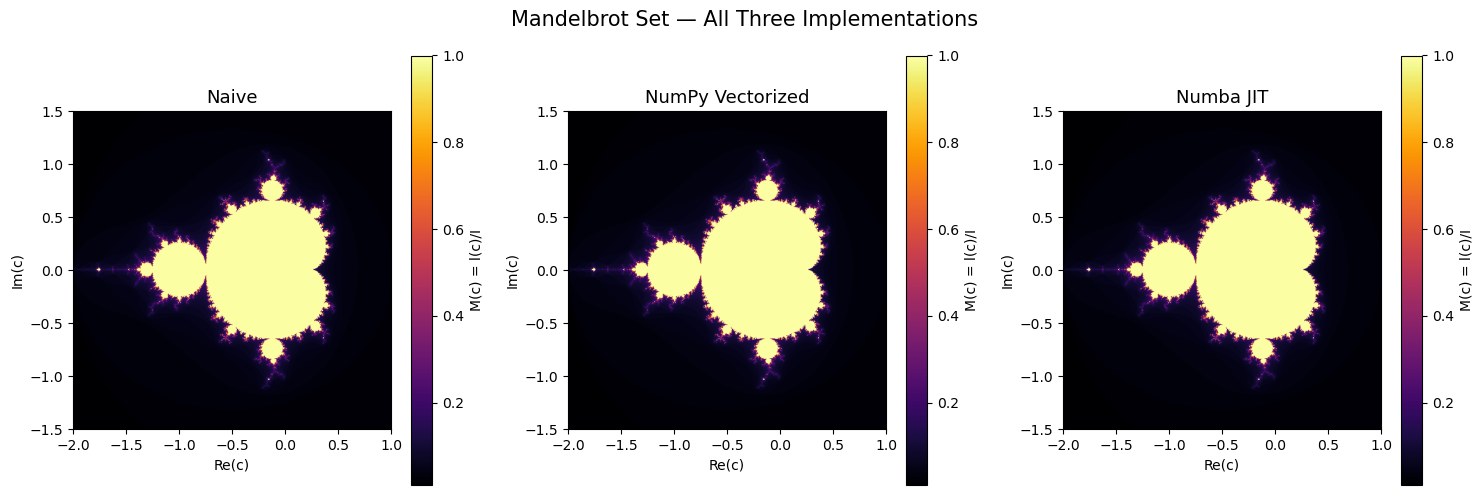

In [99]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

titles = ['Naive', 'NumPy Vectorized', 'Numba JIT']
matrices = [M_naive, M_vectorized, M_numba]

for ax, title, M in zip(axes, titles, matrices):
    im = ax.imshow(M, extent=[re_min, re_max, im_min, im_max],
                   origin='lower', cmap='inferno', aspect='equal')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    plt.colorbar(im, ax=ax, label='M(c) = l(c)/I')

plt.suptitle('Mandelbrot Set — All Three Implementations', fontsize=15)
plt.tight_layout()
plt.show()

## 3. Performance and Scaling Analysis

To perform a comprehensive scaling analysis, we sweep through gradually increasing grid resolutions.
We measure the execution time for all three implementations (Naive, NumPy, and Numba) at each resolution. 

The timing results are stored in a Pandas DataFrame, exported to a CSV file for submission, and finally visualized using a line chart to clearly illustrate the performance differences and scalability of each approach.

### 3.1 Benchmarking Methodology
Following the golden rule of code optimization, we must "Never ever optimize in the blind - always (!!!) profile before optimizing" (NSC_26_Lec02, Slide 29).

To perform our scaling analysis, we "Start small" and "increase gradually → reach sizes where naive version takes dozens of seconds or even up to a few minutes" (NSC_26_MiniProject_I_Guidelines, Slide 8). We "Measure execution time of all three versions" and "Use consistent parameters" across our benchmarks (NSC_26_MiniProject_I_Guidelines, Slide 8).

The fixed region is $-2\le\mathfrak{R}\{c\}\le1$ and $-1.5\le\mathfrak{I}\{c\}\le1.5$, and we typically use a `max_iter` of 100. A warm-up run is included for the Numba function to ensure compilation time is not included in the final metrics.

In [ ]:
import pandas as pd

resolutions = [100, 300, 600, 1000, 1500, 2000, 2500, 3000, 3500, 4000]
results = []

print("Starting performance analysis across different resolutions...")

for N in resolutions:
    print(f"Testing resolution: {N}x{N}")
    
    t0 = time.time()
    _ = mandelbrot_naive(re_min, re_max, im_min, im_max, N, N, max_iter)
    t_naive = time.time() - t0
    
    t0 = time.time()
    _ = mandelbrot_vectorized(re_min, re_max, im_min, im_max, N, N, max_iter)
    t_numpy = time.time() - t0
    
    t0 = time.time()
    _ = mandelbrot_numba(re_min, re_max, im_min, im_max, N, N, max_iter)
    t_numba = time.time() - t0
    
    results.append({
        'Resolution (NxN)': N,
        'Naive Time (s)': t_naive,
        'NumPy Time (s)': t_numpy,
        'Numba Time (s)': t_numba
    })

df_results = pd.DataFrame(results)

df_results['Speedup NumPy vs Naive'] = (
    df_results['Naive Time (s)'] / df_results['NumPy Time (s)']
).round(2)

df_results['Speedup Numba vs Naive'] = (
    df_results['Naive Time (s)'] / df_results['Numba Time (s)']
).round(2)

df_results['Speedup Numba vs NumPy'] = (
    df_results['NumPy Time (s)'] / df_results['Numba Time (s)']
).round(2)

print("Speedup Analysis:")
display(df_results)

df_results.to_csv('timing_results.csv', index=False)

Starting performance analysis across different resolutions...
Testing resolution: 100x100
Testing resolution: 300x300


Testing resolution: 600x600
Testing resolution: 1000x1000
Testing resolution: 1500x1500


KeyboardInterrupt: 

### 4. Experimental Results
The graph below plots the execution times of the three implementations as the grid resolution $N$ increases. As observed, the Naive execution time grows quadratically with the problem size, since doubling N quadruples the number of pixels, resulting in O(N²) total work, whereas the NumPy and Numba implementations remain significantly flatter, indicating vastly superior scaling. 

The Numba implementation consistently outperforms the NumPy version, especially at higher resolutions, demonstrating the benefits of JIT compilation for computationally intensive tasks.


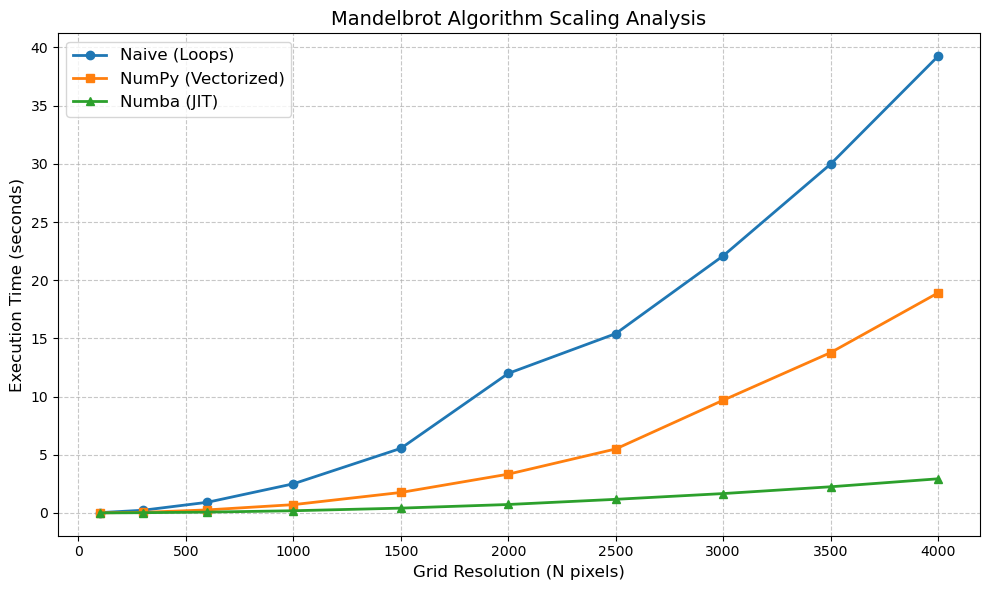

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df_results['Resolution (NxN)'], df_results['Naive Time (s)'], marker='o', label='Naive (Loops)', linewidth=2)
plt.plot(df_results['Resolution (NxN)'], df_results['NumPy Time (s)'], marker='s', label='NumPy (Vectorized)', linewidth=2)
plt.plot(df_results['Resolution (NxN)'], df_results['Numba Time (s)'], marker='^', label='Numba (JIT)', linewidth=2)

plt.title('Mandelbrot Algorithm Scaling Analysis', fontsize=14)
plt.xlabel('Grid Resolution (N pixels)', fontsize=12)
plt.ylabel('Execution Time (seconds)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The following chart shows the speedup of NumPy and Numba relative to the Naive implementation across all tested resolutions.

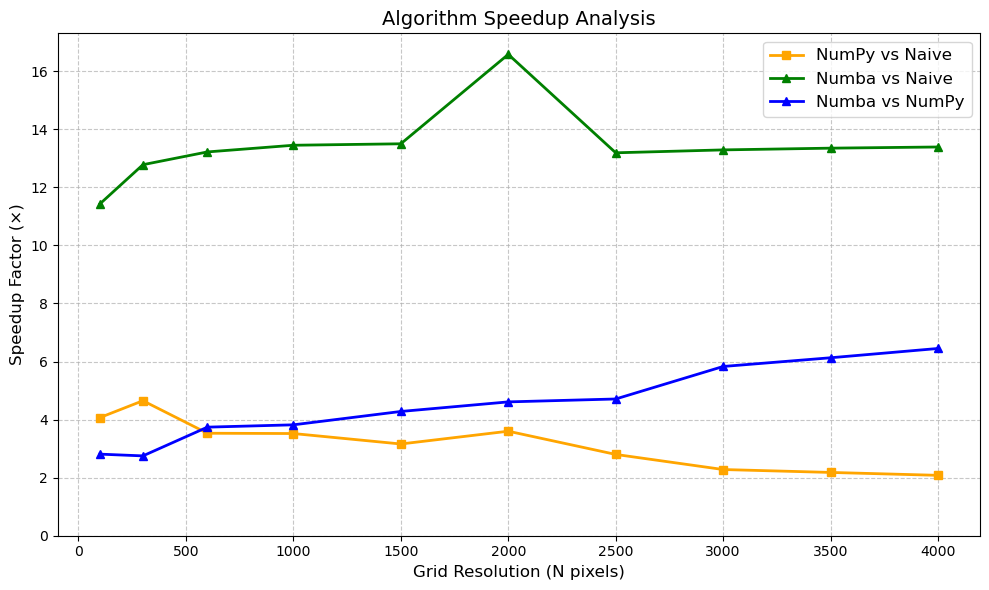

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_results['Resolution (NxN)'], 
         df_results['Speedup NumPy vs Naive'], 
         marker='s', label='NumPy vs Naive', linewidth=2, color='orange')
plt.plot(df_results['Resolution (NxN)'], 
         df_results['Speedup Numba vs Naive'], 
         marker='^', label='Numba vs Naive', linewidth=2, color='green')
plt.plot(df_results['Resolution (NxN)'], 
         df_results['Speedup Numba vs NumPy'], 
         marker='^', label='Numba vs NumPy', linewidth=2, color='blue')
plt.title('Algorithm Speedup Analysis', fontsize=14)
plt.xlabel('Grid Resolution (N pixels)', fontsize=12)
plt.ylabel('Speedup Factor (×)', fontsize=12)
plt.ylim(bottom=0)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5. Reasoning and Interpretation
The performance analysis reveals significant differences between the implementations. The Mandelbrot set is "Computationally intensive" and the "Naive version is slow → need optimization!" (NSC_26_Mandelbrot_Set, Slide 4).

**Interpreter Overhead vs. Hardware Utilization:**
Because "Each pixel independent", this is an embarrassingly parallel problem, making it "Perfect for multiprocessing, GPU, and distributed computing" (NSC_26_Mandelbrot_Set, Slide 4). 

The Naive approach struggles because the Python interpreter must evaluate every operation inside the nested loops dynamically. "Algorithmic intensity describes the amount of floating-point operations relative to the total number of bytes processed by an algorithm" (NSC_26_Lec02, Slide 17). While floating-point operations are critical, "Most modern processors and algorithms lead to memory bound computations" (NSC_26_Lec02, Slide 30) , meaning "the hardware can deliver more floating-point performance than data can be transferred to the ALU(s)" (NSC_26_Lec02, Slide 20).
Scache line utilization even in the naive implementation. easy prefetching and minimal cache line waste.



**Memory Management, Caching, and Locality:**
"Memory access is today the most critical issue for overall computing performance." (NSC_26_Lec01, Slide 26). When the CPU needs data, it checks the fast local L1/L2/L3 caches. "If data is not found in cache, it is a cache miss" (NSC_26_Lec01, Slide 31).

Our NumPy implementation heavily mitigates this by applying boolean masks. By cutting out pixels that have already escaped the threshold, we avoid useless computations and unnecessary memory writes. "This keeps the active working dataset smaller and closer to the CPU, exploiting Temporal Locality so that "the data stays in cache as long as we are using them" (NSC_26_Lec02, Slide 12). It also exploits Spatial Locality by performing contiguous array operations rather than fragmented data fetching, avoiding the penalties of long "Striding: accessing every nth element in memory." (NSC_26_Lec02, Slide 13).


Numba outperforms both by performing JIT compilation. It compiles the nested loops directly into machine code, which allows the CPU to keep intermediate variables (like $z$ and $c$) entirely inside its ultra-fast hardware registers, bypassing the latency of reading and writing to main memory altogether.